In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# BCELoss

## reduction='sum'

In [63]:
loss_fn = nn.BCELoss(reduction='sum')

In [64]:
x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(x_i) + (1 - y_i) * torch.log(1 - x_i))

loss, s

(tensor(4.2714), tensor(4.2714))

In [4]:
x = torch.rand((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(x_i_j) + (1 - y_i_j) * torch.log(1 - x_i_j))

loss, s

(tensor(33.5027), tensor(33.5027))

## reduction="mean"

In [6]:
loss_fn = nn.BCELoss(reduction='mean')

In [11]:
x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(x_i) + (1 - y_i) * torch.log(1 - x_i))

loss, s / len(x)

(tensor(0.7019), tensor(0.7019))

In [20]:
x = torch.rand((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(x_i_j) + (1 - y_i_j) * torch.log(1 - x_i_j))

loss, s / len(x.ravel())

(tensor(1.0835), tensor(1.0835))

Для BCELoss(reduction='mean') и входных данных в виде набора векторов (матрица), мы получаем что ошибка усредняется по каждому элементу, а не по вектору!

## reduction='none'

In [112]:
inputs = torch.tensor([0.0, 0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0])
targets = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
nn.BCELoss(reduction='none')(inputs, targets)

tensor([100.0000,   4.6052,   2.3026,   1.6094,   0.9163,   0.5108,   0.2231,
          0.1054,  -0.0000])

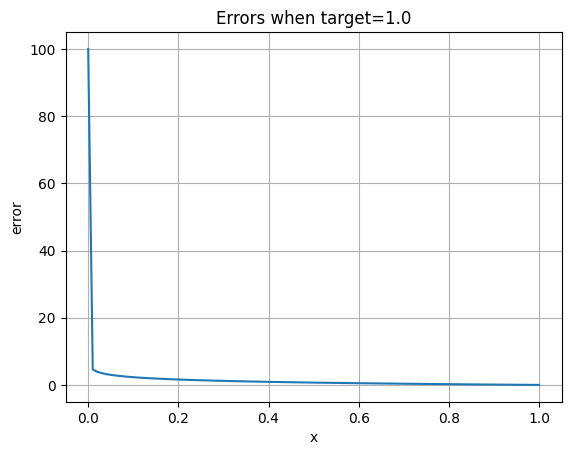

In [113]:
inputs = torch.linspace(0, 1, 100)
targets = torch.ones_like(inputs)
plt.plot(inputs, nn.BCELoss(reduction='none')(inputs, targets));
plt.xlabel('x')
plt.ylabel('error')
plt.title(f'Errors when target={targets[0]}')
plt.grid();

In [114]:
inputs = torch.tensor([0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
targets = torch.tensor([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
nn.BCELoss(reduction='none')(inputs, targets)

tensor([50.0000,  1.2040,  0.7803,  0.6931,  0.7803,  1.2040, 50.0000])

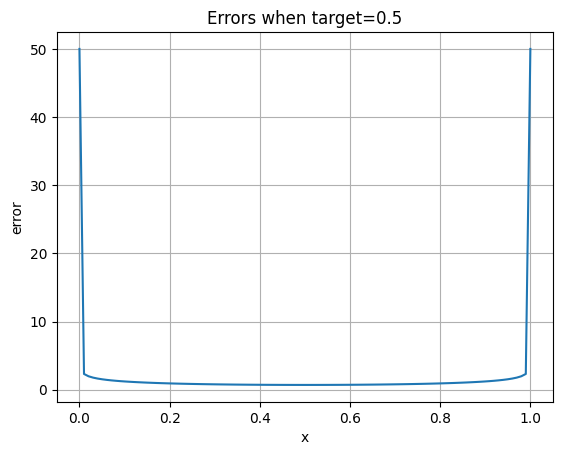

In [118]:
inputs = torch.linspace(0, 1, 100)
targets = torch.full_like(inputs, 0.5)
plt.plot(inputs, nn.BCELoss(reduction='none')(inputs, targets))
plt.xlabel('x')
plt.ylabel('error')
plt.title(f'Errors when target={targets[0]}')
plt.grid();

# BCEWithLogitsLoss

In [ ]:
loss_fn = nn.BCEWithLogitsLoss(reduction='sum')

In [3]:
x = torch.randn(10) # input, both negative and positive values
y = torch.rand(10) # target, contains values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(F.sigmoid(x_i)) + (1 - y_i) * torch.log(1 - F.sigmoid(x_i)))

loss, s

(tensor(8.3882), tensor(8.3882))

In [5]:
x = torch.randn((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(F.sigmoid(x_i_j)) + (1 - y_i_j) * torch.log(1 - F.sigmoid(x_i_j)))

loss, s

(tensor(23.5631), tensor(23.5631))

# BCELoss vs MSELoss

In [75]:
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

xx, yy = np.meshgrid(np.linspace(0.01, 0.99, 100), np.linspace(0.01, 0.99, 100))
xx = torch.Tensor(xx)
yy = torch.Tensor(yy)
bce_zz = []
mse_zz = []

for x, y in zip(xx.ravel(), yy.ravel()):
    bce_zz.append(bce_loss(x, y))
    mse_zz.append(mse_loss(x, y))

bce_zz = np.array(bce_zz).reshape(xx.shape)
mse_zz = np.array(mse_zz).reshape(xx.shape)

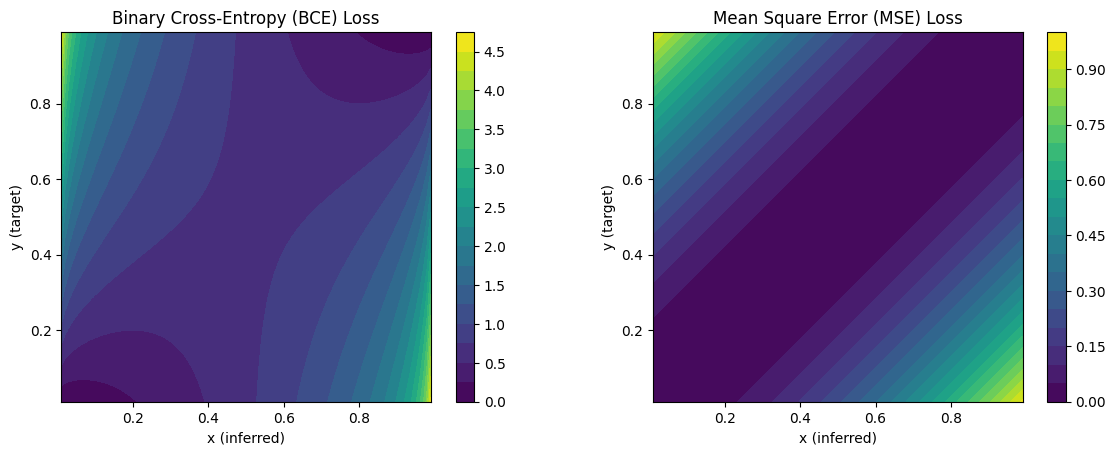

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(14)

im = ax1.contourf(xx, yy, bce_zz, levels=20, cmap='viridis')
ax1.set_aspect('equal')
ax1.set_xlabel('x (inferred)')
ax1.set_ylabel('y (target)')
ax1.set_title('Binary Cross-Entropy (BCE) Loss')
fig.colorbar(im, ax=ax1);

im = ax2.contourf(xx, yy, mse_zz, levels=20, cmap='viridis')
ax2.set_aspect('equal')
ax2.set_xlabel('x (inferred)')
ax2.set_ylabel('y (target)')
ax2.set_title('Mean Square Error (MSE) Loss')
fig.colorbar(im, ax=ax2);